In [238]:
import numpy as np
import functools
import scipy.signal
from scipy.integrate import solve_ivp
from matplotlib import pyplot as pp
import matplotlib.pyplot as plt
import pickle
import torch

In [239]:
with open('/Users/anshgrover/AIDA3/PINN-tutorial/data/massdamper_data.pkl', 'rb') as f:
    data = pickle.load(f)

data_sampled_random_with_noise = data['data_sampled_random_with_noise']
model_name = 'No external force'
sparsity   = 'sparcity level 100'
t_obs = torch.tensor(data_sampled_random_with_noise[model_name][sparsity]['t'], dtype=torch.float64)
y_obs = torch.tensor(data_sampled_random_with_noise[model_name][sparsity]['x'], dtype=torch.float64)
n = len(t_obs)
p = 1

delta  = 0.0750
omega0 = 0.3162


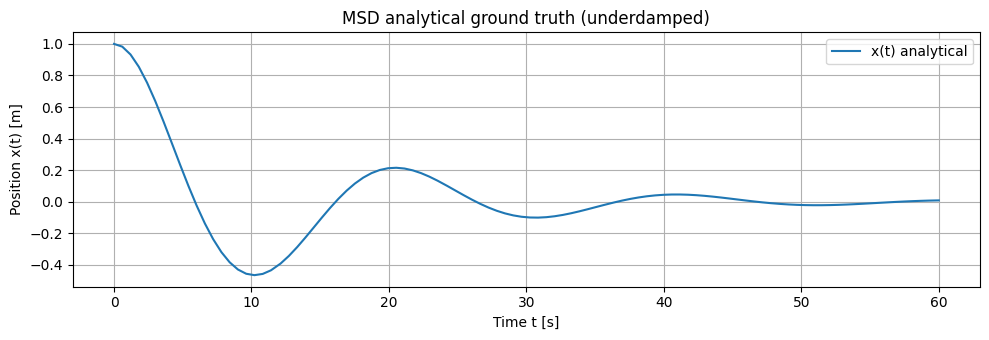

In [240]:
# ---------------------------
# Physical parameters
# ---------------------------
m_true = 2.0    # mass          [kg]
c_true = 0.3    # damping coeff [Ns/m]
k_true = 0.2    # spring const  [N/m]
delta_msd  = c_true / (2 * m_true)          # 0.075
omega0_msd = np.sqrt(k_true / m_true)       # 0.3162

print(f"delta  = {delta_msd:.4f}")
print(f"omega0 = {omega0_msd:.4f}")
x0     = [1.0, 0.0]
t_span     = (t_obs[0], t_obs[-1])

def mass_damper(delta,omega0,t): 
    omega = np.sqrt(omega0**2 - delta**2)
    phi = np.arctan(-delta/omega)
    A = 1/(2*np.cos(phi))
    coss = np.cos(phi+omega*t)
    exp = np.exp(-delta*t)
    y = exp*2*A*coss
    return y

y_exact = mass_damper(delta_msd, omega0_msd, t_obs)

pp.figure(figsize=(10, 3.5))
pp.plot(t_obs, y_exact, label='x(t) analytical')
pp.xlabel('Time t [s]')
pp.ylabel('Position x(t) [m]')
pp.title('MSD analytical ground truth (underdamped)')
pp.legend(); pp.grid(True); pp.tight_layout(); pp.show()

In [241]:
# ---------------------------
# Theorem 2: h/m_sub <= O(n^{-5/(2K)}),  K=4
# ---------------------------
n     = len(t_obs)
h     = t_obs[1] - t_obs[0]
K     = 4

theorem2_bound = n ** (-5 / (2 * K))
m_sub          = int(np.ceil(h / theorem2_bound))
step_size      = h / m_sub

print(f"n                = {n}")
print(f"h                = {h:.4f} s")
print(f"n^(-5/8)         = {theorem2_bound:.4f}  (Theorem 2 bound)")
print(f"m_sub required   = {m_sub}")
print(f"actual step size = {step_size:.4f} s")
print(f"Theorem 2 satisfied? {step_size <= theorem2_bound}")

n                = 100
h                = 0.6010 s
n^(-5/8)         = 0.0562  (Theorem 2 bound)
m_sub required   = 11
actual step size = 0.0546 s
Theorem 2 satisfied? True


Max position error (LAP vs ground truth): 1.24e-09


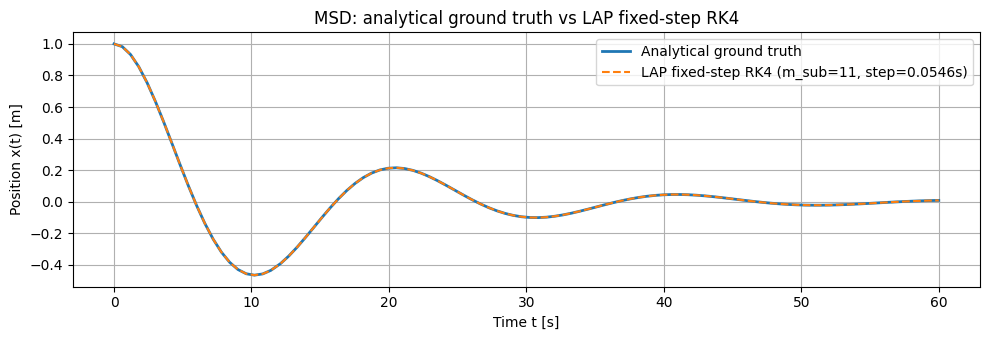

In [242]:
# ---------------------------
# ODE in PyTorch
# ---------------------------
def msd(t, y, delta, omega0):
    if not torch.is_tensor(y):
        y = torch.tensor(y, dtype=torch.float64)
    x, v = y[0], y[1]
    return torch.stack([v, -2*delta*v - omega0**2*x])

# ---------------------------
# RK4 in PyTorch — autograd tracks through this
# ---------------------------
def rk4_integrate(f, t_eval, y0, m_sub):
    if not torch.is_tensor(y0):
        y0 = torch.tensor(y0, dtype=torch.float64)
    if not torch.is_tensor(t_eval):
        t_eval = torch.tensor(t_eval, dtype=torch.float64)

    Y = [y0]
    y = y0
    for i in range(1, len(t_eval)):
        dt = (t_eval[i] - t_eval[i-1]).item()
        h  = dt / m_sub
        yi = y
        ti = t_eval[i-1].item()
        for _ in range(m_sub):
            k1 = f(ti,       yi            )
            k2 = f(ti + h/2, yi + h/2 * k1)
            k3 = f(ti + h/2, yi + h/2 * k2)
            k4 = f(ti + h,   yi + h   * k3)
            yi = yi + (h/6) * (k1 + 2*k2 + 2*k3 + k4)
            ti += h
        y = yi
        Y.append(y)
    return torch.stack(Y)


msd_fixed = functools.partial(msd,
                              delta=torch.tensor(delta_msd, dtype=torch.float64),
                              omega0=torch.tensor(omega0_msd, dtype=torch.float64))

Y_lap  = rk4_integrate(msd_fixed, t_obs, x0, m_sub)
x_pred = Y_lap[:, 0]


err = np.max(np.abs(x_pred.detach().numpy() - y_exact.numpy()))
print(f"Max position error (LAP vs ground truth): {err:.2e}")

pp.figure(figsize=(10, 3.5))
pp.plot(t_obs, y_exact, lw=2,  label='Analytical ground truth')
pp.plot(t_obs, x_pred.detach().numpy(),  '--',  label=f'LAP fixed-step RK4 (m_sub={m_sub}, step={step_size:.4f}s)')
pp.xlabel('Time t [s]')
pp.ylabel('Position x(t) [m]')
pp.title('MSD: analytical ground truth vs LAP fixed-step RK4')
pp.legend(); pp.grid(True); pp.tight_layout(); pp.show()

In [ ]:
n = len(t_obs)
p = 1
print(f"n={n}, p={p}")

n=100, p=1


In [ ]:
def compute_gn(x_pred, y_obs):
    if not torch.is_tensor(x_pred):
        x_pred = torch.tensor(x_pred, dtype=torch.float64)
    if not torch.is_tensor(y_obs):
        y_obs  = torch.tensor(y_obs,  dtype=torch.float64)
    return torch.mean((y_obs - x_pred)**2)
gn_val = compute_gn(x_pred, y_obs)
print(f"g_n at true theta and true x1 = {gn_val:.6f}")
print(f"Expected ~sigma^2 = {0.1**2:.4f}")

g_n at true theta and true x1 = 0.008590
Expected ~sigma^2 = 0.0100


In [246]:
# ---------------------------
# g̈_n via autograd through our own RK4
# ---------------------------
def compute_gn_dd_autograd(x1_val, theta):
    delta, omega0 = theta

    x1          = torch.tensor(x1_val, requires_grad=True, dtype=torch.float64)
    y0          = torch.stack([x1, torch.tensor(0.0, dtype=torch.float64)])

    f      = lambda t, y: msd(t, y, delta, omega0)
    Y      = rk4_integrate(f, t_obs, y0, m_sub)
    x_pred = Y[:, 0]

    gn         = compute_gn(x_pred, y_obs)
    dgn        = torch.autograd.grad(gn, x1, create_graph=True)[0]
    d2gn       = torch.autograd.grad(dgn, x1)[0]

    return d2gn.item()

# ---------------------------
# Test
# ---------------------------
gn_dd_val = compute_gn_dd_autograd(x0[0], theta_true)
print(f"g̈_n via autograd = {gn_dd_val:.6f}")

g̈_n via autograd = 0.145248


In [323]:
from scipy.optimize import minimize_scalar
# ---------------------------
# Prior hyperparameters
# ---------------------------
mu_x1 = y_obs[0].item()    # prior mean for x_1 = first noisy observation
c     = 100.0       # weak prior on x_1
a     = 0.1         # Gamma prior shape on tau^2
b     = 0.01        # Gamma prior rate on tau^2


# ---------------------------
# Step 2: Find x_hat_1(theta)
# Minimize: n*g_n(x1, theta) + (x1 - mu_x1)^2 / c
# x1 is scalar (initial position), velocity fixed at 0
# ---------------------------

def objective_x1(x1, theta):
    delta, omega0  = theta
    f              = functools.partial(msd, delta=delta, omega0=omega0)
    Y              = rk4_integrate(f, t_obs, [x1, 0.0], m_sub)
    x_pred         = Y[:, 0]
    gn             = compute_gn(x_pred, y_obs)
    penalty        = (x1 - mu_x1)**2 / c
    return (n * gn).item() + penalty

# ---------------------------
# Test at true parameters
# ---------------------------
theta_true = np.array([delta_msd, omega0_msd])
bounds_x1 = (y_obs.min().item(), y_obs.max().item())

result = minimize_scalar(objective_x1, bounds=bounds_x1,
                         method='bounded', args=(theta_true,))
x1_hat = result.x

print(f"x1_hat          = {x1_hat:.6f}")
print(f"true x1         = {x0[0]:.6f}")
print(f"mu_x1           = {mu_x1:.6f}")
print(f"objective value = {result.fun:.6f}")

x1_hat          = 0.981509
true x1         = 1.000000
mu_x1           = 1.067884
objective value = 0.856582


In [324]:
def find_x1hat_torch(theta):
    delta, omega0 = theta[0], theta[1]
    x1 = torch.tensor([mu_x1], requires_grad=True, dtype=torch.float64)
    optimizer = torch.optim.LBFGS([x1], lr=1.0, max_iter=100)

    def closure():
        optimizer.zero_grad()
        f      = functools.partial(msd, delta=delta, omega0=omega0)
        Y      = rk4_integrate(f, t_obs, torch.stack([x1[0], torch.tensor(0.0, dtype=torch.float64)]), m_sub)
        x_pred = Y[:, 0]
        gn     = compute_gn(x_pred, y_obs)
        loss   = n * gn + (x1[0] - mu_x1)**2 / c
        loss.backward()
        return loss

    optimizer.step(closure)
    return x1[0]

find_x1hat_torch(theta_true)

tensor(0.9815, dtype=torch.float64, grad_fn=<SelectBackward0>)

In [325]:
def compute_u(x1_hat, theta):
    delta, omega0 = theta
    f             = functools.partial(msd, delta=delta, omega0=omega0)
    Y             = rk4_integrate(f, t_obs, [x1_hat, 0.0], m_sub)
    x_pred        = Y[:, 0]
    gn            = compute_gn(x_pred, y_obs)
    u             = n * gn + (x1_hat - mu_x1)**2 / c
    return u, x_pred

u_val, x_pred_hat = compute_u(x1_hat, theta_true)

print(f"u(theta) = {u_val:.6f}")

u(theta) = 0.856582


In [326]:
def compute_v(x1_hat, theta):
    gn_dd = compute_gn_dd_autograd(x1_hat, theta)
    H     = n * gn_dd + 2.0 / c     # scalar since p=1
    return np.log(H)

print(compute_v(x1_hat, theta_true))

2.677232142762964


In [327]:
def lap_posterior(theta):
    delta  = theta[0]
    omega0 = theta[1]
    theta_t = (delta, omega0)

    # --- find x̂_1(θ) ---
    x1_hat = find_x1hat_torch(theta).detach()

    # --- u(θ) ---
    u, _ = compute_u(x1_hat, theta_t)
    if u <= 0:
        return torch.tensor(-torch.inf, dtype=torch.float64)

    # --- v(θ) ---
    gn_dd = compute_gn_dd_autograd(x1_hat.item(), theta_t)
    H     = n * gn_dd + 2.0 / c
    if H <= 0:
        return torch.tensor(-torch.inf, dtype=torch.float64)
    v = torch.log(torch.tensor(H, dtype=torch.float64))

    # --- log π(θ|y_n) ---
    log_pi = -(n * p / 2 + a) * torch.log(u / 2 + b) - 0.5 * v
    return log_pi

def lap_posterior_u(theta):
    delta  = theta[0]
    omega0 = theta[1]
    theta_t = (delta, omega0)

    # --- find x̂_1(θ) ---
    x1_hat = find_x1hat_torch(theta).detach()

    # --- u(θ) ---
    u, _ = compute_u(x1_hat, theta_t)
    if u <= 0:
        return torch.tensor(-torch.inf, dtype=torch.float64)

    # --- v(θ) ---
    gn_dd = compute_gn_dd_autograd(x1_hat.item(), theta_t)
    H     = n * gn_dd + 2.0 / c
    if H <= 0:
        return torch.tensor(-torch.inf, dtype=torch.float64)
    v = torch.log(torch.tensor(H, dtype=torch.float64))

    # --- log π(θ|y_n) ---
    log_pi = -(n * p / 2 + a) * torch.log(u / 2 + b) - 0.5 * v
    return log_pi, u

In [336]:
print(lap_posterior(theta_true))

tensor(39.9875, dtype=torch.float64)


In [329]:
33.7 - 0.5 * 2.677232142762964

32.36138392861852

In [330]:
print(lap_posterior([0.1,0.1]))

tensor(-65.6579, dtype=torch.float64)


In [353]:
# --- construct grid ---
delta_grid  = np.linspace(0.01, 0.2,  10)
omega0_grid = np.linspace(0.1,  0.6,  10)

log_pi = np.zeros((10, 10))

for i, delta in enumerate(delta_grid):
    for j, omega0 in enumerate(omega0_grid):
        log_pi[j, i] = lap_posterior([delta, omega0])
        print(f"({i},{j}) delta={delta:.3f} omega0={omega0:.3f} → {log_pi[j,i]:.2f}")

# --- normalize ---
log_pi_shifted = log_pi - np.max(log_pi)   # subtract max for numerical stability
pi             = np.exp(log_pi_shifted)
pi            /= pi.sum()                   # normalize to sum to 1

# --- MAP estimate (peak of the grid) ---
j_map, i_map = np.unravel_index(np.argmax(pi), pi.shape)
delta_map    = delta_grid[i_map]
omega0_map   = omega0_grid[j_map]

print(f"delta  MAP = {delta_map:.4f}  (true: {delta_msd:.4f})")
print(f"omega0 MAP = {omega0_map:.4f}  (true: {omega0_msd:.4f})")

# --- marginal means ---
delta_mean  = np.sum(pi.sum(axis=0) * delta_grid)
omega0_mean = np.sum(pi.sum(axis=1) * omega0_grid)

print(f"delta  mean = {delta_mean:.4f}")
print(f"omega0 mean = {omega0_mean:.4f}")

(0,0) delta=0.010 omega0=0.100 → -67.97
(0,1) delta=0.010 omega0=0.156 → -65.53
(0,2) delta=0.010 omega0=0.211 → -63.24
(0,3) delta=0.010 omega0=0.267 → -48.72
(0,4) delta=0.010 omega0=0.322 → -40.30
(0,5) delta=0.010 omega0=0.378 → -61.73
(0,6) delta=0.010 omega0=0.433 → -68.91
(0,7) delta=0.010 omega0=0.489 → -70.04
(0,8) delta=0.010 omega0=0.544 → -70.74
(0,9) delta=0.010 omega0=0.600 → -70.59
(1,0) delta=0.031 omega0=0.100 → -65.58
(1,1) delta=0.031 omega0=0.156 → -60.77
(1,2) delta=0.031 omega0=0.211 → -53.64
(1,3) delta=0.031 omega0=0.267 → -27.83
(1,4) delta=0.031 omega0=0.322 → -7.83
(1,5) delta=0.031 omega0=0.378 → -47.34
(1,6) delta=0.031 omega0=0.433 → -63.75
(1,7) delta=0.031 omega0=0.489 → -67.93
(1,8) delta=0.031 omega0=0.544 → -69.80
(1,9) delta=0.031 omega0=0.600 → -69.79
(2,0) delta=0.052 omega0=0.100 → -64.79
(2,1) delta=0.052 omega0=0.156 → -58.16
(2,2) delta=0.052 omega0=0.211 → -46.40
(2,3) delta=0.052 omega0=0.267 → -13.12
(2,4) delta=0.052 omega0=0.322 → 25.03
(2

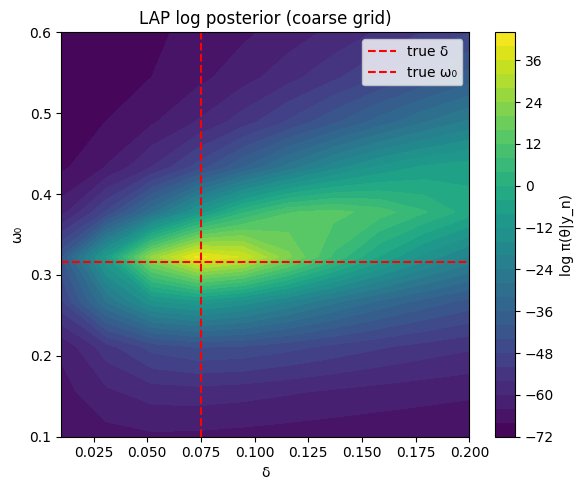

In [354]:
pp.figure(figsize=(6,5))
pp.contourf(delta_grid, omega0_grid, log_pi, levels=30, cmap='viridis')
pp.colorbar(label='log π(θ|y_n)')
pp.axvline(delta_msd,  color='r', linestyle='--', label='true δ')
pp.axhline(omega0_msd, color='r', linestyle='--', label='true ω₀')
pp.xlabel('δ'); pp.ylabel('ω₀')
pp.title('LAP log posterior (coarse grid)')
pp.legend(); pp.tight_layout(); pp.show()

In [356]:

theta0 = torch.tensor(theta_true, dtype=torch.float64)

H = torch.autograd.functional.hessian(lap_posterior, torch.tensor(theta0, dtype=torch.float64))
neg_H = -H.numpy()

# eigendecompose
eigenvalues, U = np.linalg.eigh(neg_H)
eigenvalues    = np.maximum(eigenvalues, 1e-8)
A              = np.matmul(U, np.diag(eigenvalues ** -0.5))

# --- Step 2: coarse scan over z ∈ [-4, 4]^q ---
M1    = 3
eta   = 1e-5
z_1d  = np.linspace(-4, 4, 2*M1 + 1)

A_bounds = []   # will hold [A_i, B_i] for each dimension
B_bounds = []

print(z_1d)
for dim in range(len(theta0)):
    active = []
    for z_val in z_1d:
        z          = np.zeros(len(theta0))
        z[dim]     = z_val
        theta_test = theta0 + A @ z
        lp        = lap_posterior(theta_test)
        if lp > np.log(eta):
            active.append(z_val)
    A_bounds.append(min(active) if active else -4)
    B_bounds.append(max(active) if active else  4)

print(f"Coarse scan bounds in z-space:")
for i in range(len(theta0)):
    print(f"  z[{i}]: [{A_bounds[i]:.2f}, {B_bounds[i]:.2f}]")

/var/folders/qb/4gqyhj5d15728855vcb9k79w0000gn/T/ipykernel_12709/203404650.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  H = torch.autograd.functional.hessian(lap_posterior, torch.tensor(theta0, dtype=torch.float64))


[-4.         -2.66666667 -1.33333333  0.          1.33333333  2.66666667
  4.        ]
Coarse scan bounds in z-space:
  z[0]: [-4.00, 4.00]
  z[1]: [-4.00, 4.00]


In [357]:
M2     = 10
z0_1d  = np.linspace(A_bounds[0], B_bounds[0], 2*M2 + 1)
z1_1d  = np.linspace(A_bounds[1], B_bounds[1], 2*M2 + 1)

Z0, Z1  = np.meshgrid(z0_1d, z1_1d)
log_pi  = np.zeros_like(Z0)
u_grid = np.zeros_like(Z0)

In [358]:
for i in range(Z0.shape[0]):
    for j in range(Z0.shape[1]):
        z          = np.array([Z0[i,j], Z1[i,j]])
        theta_ij   = theta0 + A @ z
        log_pi[i,j], u_grid[i,j] = lap_posterior_u(theta_ij)
        print(f"({i},{j}) θ=({theta_ij[0]:.3f},{theta_ij[1]:.3f}) → {log_pi[i,j]:.2f}")


(0,0) θ=(0.099,0.319) → 30.78
(0,1) θ=(0.097,0.318) → 30.89
(0,2) θ=(0.096,0.316) → 30.95
(0,3) θ=(0.094,0.315) → 30.95
(0,4) θ=(0.093,0.314) → 30.89
(0,5) θ=(0.092,0.312) → 30.76
(0,6) θ=(0.090,0.311) → 30.56
(0,7) θ=(0.089,0.310) → 30.30
(0,8) θ=(0.087,0.308) → 29.95
(0,9) θ=(0.086,0.307) → 29.53
(0,10) θ=(0.084,0.306) → 29.03
(0,11) θ=(0.083,0.305) → 28.44
(0,12) θ=(0.081,0.303) → 27.77
(0,13) θ=(0.080,0.302) → 27.01
(0,14) θ=(0.079,0.301) → 26.16
(0,15) θ=(0.077,0.299) → 25.22
(0,16) θ=(0.076,0.298) → 24.20
(0,17) θ=(0.074,0.297) → 23.09
(0,18) θ=(0.073,0.295) → 21.89
(0,19) θ=(0.071,0.294) → 20.61
(0,20) θ=(0.070,0.293) → 19.24
(1,0) θ=(0.098,0.320) → 32.05
(1,1) θ=(0.096,0.319) → 32.19
(1,2) θ=(0.095,0.317) → 32.28
(1,3) θ=(0.094,0.316) → 32.30
(1,4) θ=(0.092,0.315) → 32.27
(1,5) θ=(0.091,0.313) → 32.16
(1,6) θ=(0.089,0.312) → 31.99
(1,7) θ=(0.088,0.311) → 31.73
(1,8) θ=(0.086,0.309) → 31.40
(1,9) θ=(0.085,0.308) → 30.99
(1,10) θ=(0.083,0.307) → 30.49
(1,11) θ=(0.082,0.306) → 29.

In [359]:
# --- normalize ---
log_pi_shifted = log_pi - np.max(log_pi)   # subtract max for numerical stability
pi             = np.exp(log_pi_shifted)
pi            /= pi.sum()                   # proper probability weights

# --- draw θ^(i) samples from the discrete grid ---
N_samples   = 1000
flat_pi     = pi.flatten()
flat_idx    = np.random.choice(len(flat_pi), size=N_samples, p=flat_pi)
i_idx, j_idx = np.unravel_index(flat_idx, pi.shape)

theta_samples = np.array([
    (theta0 + A @ np.array([Z0[i,j], Z1[i,j]])).numpy()
    for i, j in zip(i_idx, j_idx)
])   # (N_samples, 2)

# --- Step 3: for each θ^(i), draw τ²^(i) ~ Gamma(np/2+a, u(θ^(i))/2+b) ---
u_flat     = u_grid.flatten()[flat_idx]
tau2_samples = np.array([
    np.random.gamma(
        shape = n*p/2 + a,
        scale = 1.0 / (u_flat[i] / 2 + b)
    )
    for i in range(N_samples)
])

In [360]:
tau2_samples.shape

(1000,)

0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
7
7
7
7
7
7
7
7
7
7
7
7
7
7
7
7
7
7
7
7
7
8
8
8
8
8
8
8
8
8
8
8
8
8
8
8
8
8
8
8
8
8
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
10
10
10
10
10
10
10
10
10
10
10
10
10
10
10
10
10
10
10
10
10
11
11
11
11
11
11
11
11
11
11
11
11
11
11
11
11
11
11
11
11
11
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
13
13
13
13
13
13
13
13
13
13
13
13
13
13
13
13
13
13
13
13
13
14
14
14
14
14
14
14
14
14
14
14
14
14
14
14
14
14
14
14
14
14
15
15
15
15
15
15
15
15
15
15
15
15
15
15
15
15
15
15
15
15
15
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
19
19
19
19
1

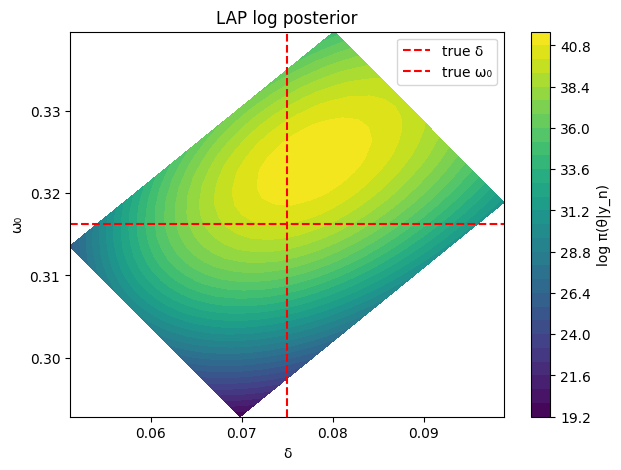

In [361]:
delta_grid_theta  = np.zeros_like(Z0)
omega0_grid_theta = np.zeros_like(Z1)

for i in range(Z0.shape[0]):
    for j in range(Z0.shape[1]):
        print(i)
        z = np.array([Z0[i,j], Z1[i,j]])
        theta_ij = (theta0 + A @ z).numpy()
        delta_grid_theta[i][j]  = theta_ij[0]
        omega0_grid_theta[i][j] = theta_ij[1]
print(delta_grid)
pp.figure(figsize=(7,5))
pp.contourf(delta_grid_theta, omega0_grid_theta, log_pi, levels=30, cmap='viridis')
pp.colorbar(label='log π(θ|y_n)')
pp.axvline(delta_msd,  color='r', linestyle='--', label='true δ')
pp.axhline(omega0_msd, color='r', linestyle='--', label='true ω₀')
pp.xlabel('δ'); pp.ylabel('ω₀')
pp.title('LAP log posterior')
pp.legend()

In [362]:
delta_mean  = np.average(theta_samples[:,0])
omega0_mean = np.average(theta_samples[:,1])
delta_std   = np.std(theta_samples[:,0])
omega0_std  = np.std(theta_samples[:,1])

print(f"δ:   true={delta_msd:.4f}  est={delta_mean:.4f}  std={delta_std:.4f}")
print(f"ω₀:  true={omega0_msd:.4f}  est={omega0_mean:.4f}  std={omega0_std:.4f}")

δ:   true=0.0750  est=0.0781  std=0.0053
ω₀:  true=0.3162  est=0.3241  std=0.0044


In [314]:
print("theta0:", theta0)
print("A:", A)
print("sample theta at z=[1,0]:", theta0 + A @ np.array([1.0, 0.0]))
print("sample theta at z=[0,1]:", theta0 + A @ np.array([0.0, 1.0]))

theta0: tensor([0.1000, 0.4000], dtype=torch.float64)
A: [[10000.     0.]
 [    0. 10000.]]
sample theta at z=[1,0]: tensor([1.0000e+04, 4.0000e-01], dtype=torch.float64)
sample theta at z=[0,1]: tensor([1.0000e-01, 1.0000e+04], dtype=torch.float64)


In [315]:
print("H:", H)


H: tensor([[0., 0.],
        [0., 0.]], dtype=torch.float64)


In [334]:

print(theta0)
H = torch.autograd.functional.hessian(lap_posterior, theta0)
neg_H = -H.numpy()

print(H)


tensor([0.1000, 0.4000], dtype=torch.float64)
tensor([[-12812.7891,   3244.6996],
        [  3244.6996,   6951.8488]], dtype=torch.float64)


In [335]:
H     = torch.autograd.functional.hessian(lap_posterior, theta0)
neg_H = -H.numpy()

eigenvalues, U = np.linalg.eigh(neg_H)
print("eigenvalues before fix:", eigenvalues)

# replace negative eigenvalues with minimum positive eigenvalue
min_pos = eigenvalues[eigenvalues > 0].min()
eigenvalues = np.where(eigenvalues <= 0, min_pos, eigenvalues)
print("eigenvalues after fix:", eigenvalues)

# reparametrization matrix A = U Λ^{-1/2}
A = U @ np.diag(eigenvalues ** -0.5)

eigenvalues before fix: [-7470.89051957 13331.83074807]
eigenvalues after fix: [13331.83074807 13331.83074807]


In [337]:
print("theta0:", theta0.numpy())
print("scale:", eigenvalues ** -0.5)
for z_val in [-4, -2, 0, 2, 4]:
    z = np.array([z_val, 0.0])
    theta_test = theta0.numpy() + A @ z
    print(f"z={z_val} → delta={theta_test[0]:.4f}")

for z_val in [-4, -2, 0, 2, 4]:
    z = np.array([0.0, z_val])
    theta_test = theta0.numpy() + A @ z
    print(f"z={z_val} → omega0={theta_test[1]:.4f}")

theta0: [0.1 0.4]
scale: [0.00866074 0.00866074]
z=-4 → delta=0.1055
z=-2 → delta=0.1027
z=0 → delta=0.1000
z=2 → delta=0.0973
z=4 → delta=0.0945
z=-4 → omega0=0.3945
z=-2 → omega0=0.3973
z=0 → omega0=0.4000
z=2 → omega0=0.4027
z=4 → omega0=0.4055


In [338]:
theta0 = torch.tensor([0.1, 0.4], dtype=torch.float64, requires_grad=True)
optimizer = torch.optim.Adam([theta0], lr=0.005)

for i in range(300):
    optimizer.zero_grad()
    loss = -lap_posterior(theta0)
    loss.backward()
    optimizer.step()
    if i % 50 == 0:
        print(f"iter {i}: theta={theta0.detach().numpy()}, log_pi={-loss.item():.4f}")

theta_map = theta0.detach().clone()
print("MAP:", theta_map)

H     = torch.autograd.functional.hessian(lap_posterior, theta_map)
neg_H = -H.numpy()
eigenvalues, U = np.linalg.eigh(neg_H)
min_pos        = eigenvalues[eigenvalues > 0].min()
eigenvalues    = np.where(eigenvalues <= 0, min_pos, eigenvalues)
A              = U @ np.diag(eigenvalues ** -0.5)
print("eigenvalues:", eigenvalues)
print("scale:", eigenvalues ** -0.5)

iter 0: theta=[0.105 0.395], log_pi=-13.0041


KeyboardInterrupt: 

In [342]:
H     = torch.autograd.functional.hessian(lap_posterior, torch.tensor(theta_true, dtype=torch.float64))

In [343]:
H

tensor([[-59945.0860,  19923.2507],
        [ 19923.2507, -64187.1432]], dtype=torch.float64)

In [ ]:
#Try JAX